### Group-level neurofeedback performance analyses

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import scipy.stats as stats

warnings.filterwarnings("ignore")

In [ ]:
PATHs = {
    "data": "../data",
    "result": "../results",
    }
SUB_without_NF = ["S#####"]

In [3]:
from utils import set_log, compute_mean_correlations, plot_errorbar, plot_marker
from utils import correlation_high_ci, correlation_low_ci, normal_high_ci, normal_low_ci

CONDITIONs = ["Anger", "Enthusiasm", "Joyfulrelaxation", "Sadness"]
logger = set_log("group_NF.log", os.path.join(PATHs["result"], "logs"), stream_handler = False)

c:\Users\xuwang\Anaconda3\envs\py36\lib\site-packages\nilearn\__init__.py:69: FutureWarning: Python 3.6 support is deprecated and will be removed in release 0.10 of Nilearn. Consider switching to Python 3.8 or 3.9.
  _python_deprecation_warnings()


#### 1. Whole-run time sequence analysis

In [4]:
def plot_corr_all_conds(target_cond_idx):
    group_df = pd.read_csv(os.path.join(PATHs["result"], "feedback", "group-performance_time-level_all-conds.csv"))
    group_df = group_df[group_df["condition"] == CONDITIONs[target_cond_idx]]
    if target_cond_idx == 2: group_df = group_df[group_df["sub_id"] != SUB_without_NF[0]]
    fig, ax = plt.subplots(figsize = (12, 10))
    line_styles = ["solid", "dashed"]
    plot_colors = ["#2B91BF", "sienna" , "#851A79", "#67976D"]
    logger.info(f"Plotting correlation curves for {CONDITIONs[target_cond_idx]}")
    for run_idx, run_desc in enumerate(["Run 1", "Run 2"]):
        if target_cond_idx == 3 and run_idx == 1: continue
        for cond_idx, cond_desc in enumerate(["cond0_correlation", "cond1_correlation", "cond2_correlation", "cond3_correlation"]):
            if cond_desc == f"cond{target_cond_idx}_correlation":
                summary_df = group_df.groupby(["run", "time"])[cond_desc].agg(mean = compute_mean_correlations, low_ci = correlation_low_ci, high_ci = correlation_high_ci).reset_index()
                run_mean = summary_df[summary_df["run"] == run_desc]["mean"]
                run_low_ci = summary_df[summary_df["run"] == run_desc]["low_ci"]
                run_high_ci = summary_df[summary_df["run"] == run_desc]["high_ci"]
                curve_label = run_desc+" & "+CONDITIONs[cond_idx] if target_cond_idx == 2 else CONDITIONs[cond_idx]
                ax.plot(np.arange(1, len(run_mean)+1), run_mean, color = plot_colors[cond_idx], label = curve_label, linestyle = line_styles[run_idx], linewidth = 6)
                ax.fill_between(np.arange(1, len(run_mean)+1), run_low_ci, run_high_ci, color = plot_colors[cond_idx], alpha = 0.05)
            else:
                summary_df = group_df.groupby(["run", "time"])[cond_desc].agg(mean = compute_mean_correlations).reset_index()
                run_mean = summary_df[summary_df["run"] == run_desc]["mean"]
                curve_label = run_desc+" & "+CONDITIONs[cond_idx] if target_cond_idx == 2 else CONDITIONs[cond_idx]
                ax.plot(np.arange(1, len(run_mean)+1), run_mean, color = plot_colors[cond_idx], label = curve_label, linestyle = line_styles[run_idx], linewidth = 4, alpha = 0.5)
    ax.legend(loc = 'upper center', fontsize = 21.5, ncol = 2)
    x_ticks = [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60]
    if target_cond_idx == 2: 
        y_ticks = [-0.1, 0.0, 0.1, 0.2, 0.3, 0.4]
        plt.ylim(-0.1, 0.46)
    elif target_cond_idx == 3: 
        y_ticks = [-0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
        plt.ylim(-0.16, 0.54)
    plt.xticks(x_ticks, ["0", "", "12", "", "24", "", "36", "", "48", "", "60"], fontsize = 25)
    plt.yticks(y_ticks, fontsize = 25)
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(PATHs["result"], "figures", f'correlation-curve_{CONDITIONs[target_cond_idx]}.png'), dpi = 300)
    # plt.close()

In [5]:
def plot_feedback_curves(target_cond_idx, target_metric):
    group_df = pd.read_csv(os.path.join(PATHs["result"], "feedback", f"group-performance_time-level_all-conds.csv"))
    group_df = group_df[group_df["condition"] == CONDITIONs[target_cond_idx]]
    if target_cond_idx == 2: group_df = group_df[group_df["sub_id"] != SUB_without_NF[0]]
    summary_df = group_df.groupby(["run", "time"])[target_metric].agg(
        mean = np.mean, low_ci = normal_low_ci, high_ci = normal_high_ci).reset_index()
    logger.info(f"Plotting feedback curves for {CONDITIONs[target_cond_idx]}")
    fig, ax = plt.subplots(figsize = (7, 5))
    line_styles = ["solid", "dashed"]
    if target_metric == "intensity":
        y_ticks = [0, 1, 2, 3]
        plot_color = "darkorange"
    elif target_metric == "angular_distance": 
        y_ticks = [45, 60, 75, 90, 105, 120]
        plot_color = "red"
    for run_idx, run_desc in enumerate(["Run 1", "Run 2"]):
        if target_cond_idx == 3 and run_idx == 1: continue
        run_mean = summary_df[summary_df["run"] == run_desc]["mean"]
        run_low_ci = summary_df[summary_df["run"] == run_desc]["low_ci"]
        run_high_ci = summary_df[summary_df["run"] == run_desc]["high_ci"]
        ax.plot(np.arange(1, len(run_mean)+1), run_mean, color = plot_color, label = run_desc, linestyle = line_styles[run_idx], linewidth = 4)
        ax.fill_between(np.arange(1, len(run_mean)+1), run_low_ci, run_high_ci, color = plot_color, alpha = 0.08)
    if target_cond_idx == 2: 
        if target_metric == "angular_distance":
            ax.legend(loc = 'upper center', fontsize = 22, ncol = 2)
        elif target_metric == "intensity":
            ax.legend(loc = 'upper center', fontsize = 22, ncol = 2)
            plt.ylim(0, 3.35)
    x_ticks = [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60]
    plt.xticks(x_ticks, ["0", "", "12", "", "24", "", "36", "", "48", "", "60"], fontsize = 25)
    plt.yticks(y_ticks, fontsize = 25)
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(PATHs["result"], "figures", f'{target_metric}-curve_{CONDITIONs[target_cond_idx]}.png'), dpi = 300)
    # plt.close()

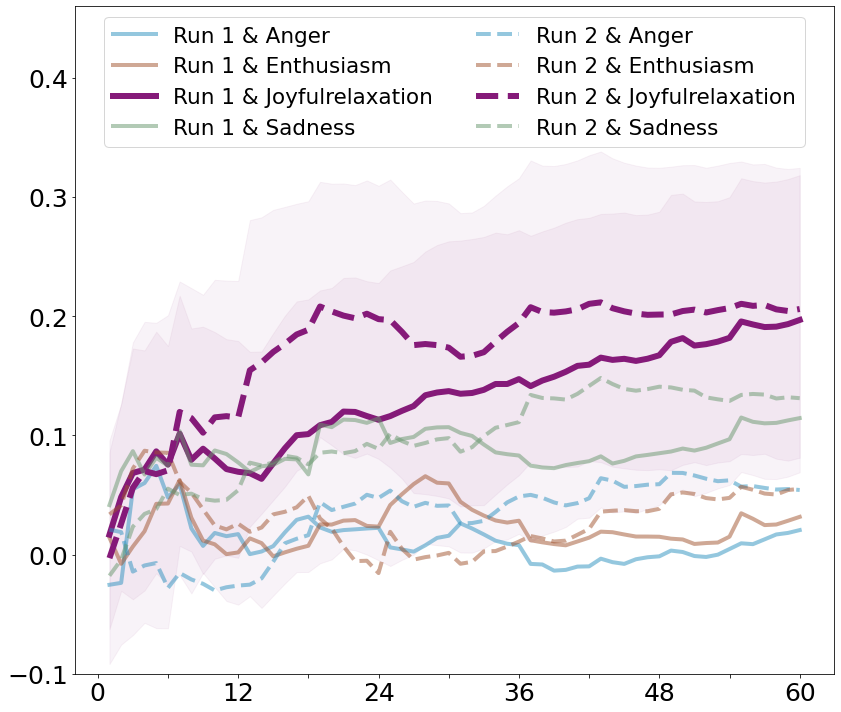

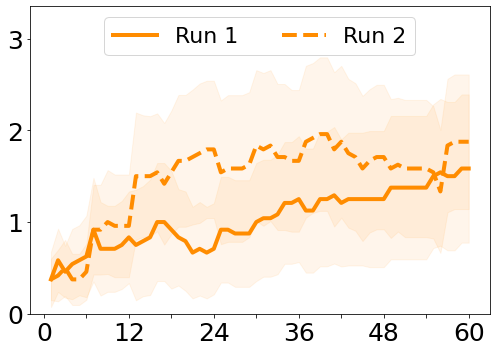

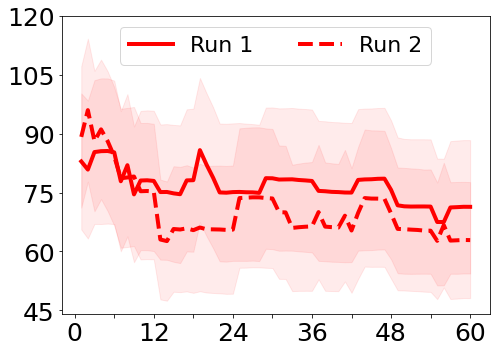

In [6]:
plot_corr_all_conds(target_cond_idx = 2)
plot_feedback_curves(target_cond_idx = 2, target_metric = "intensity")
plot_feedback_curves(target_cond_idx = 2, target_metric = "angular_distance")

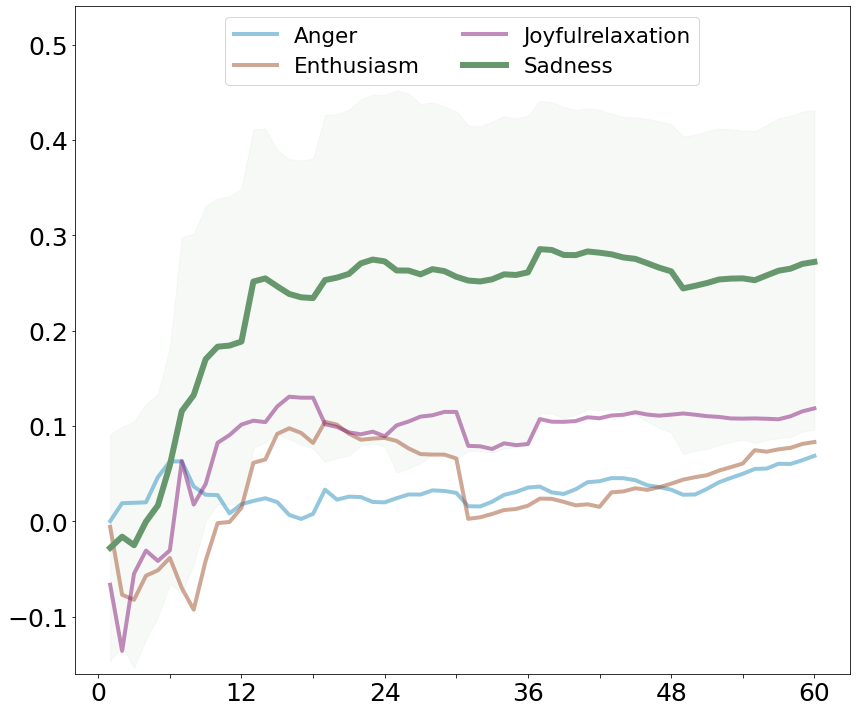

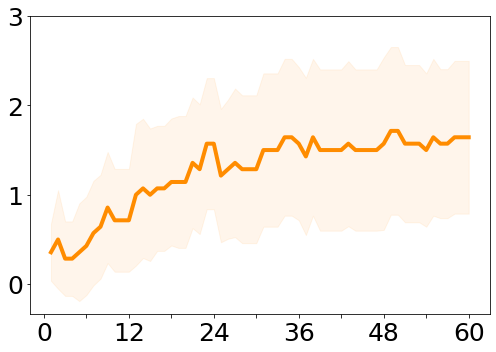

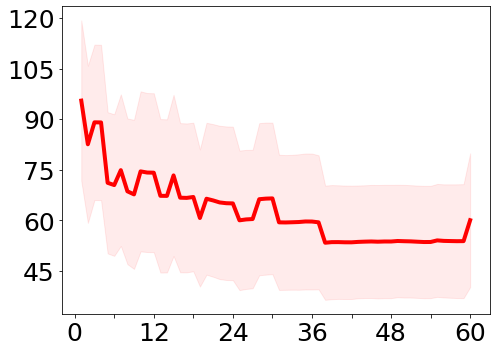

In [7]:
plot_corr_all_conds(target_cond_idx = 3)
plot_feedback_curves(target_cond_idx = 3, target_metric = "intensity")
plot_feedback_curves(target_cond_idx = 3, target_metric = "angular_distance")

#### 2. Linear mixed-effects models analysis

##### Likelihood-Ratio Test

In [8]:
# For joyful relaxation NF analysis with two runs
def compare_lmm(target_metric, time_trim, target_cond_idx = 2):
    group_df = pd.read_csv(os.path.join(PATHs["result"], "feedback", f"group-performance_time-level_all-conds.csv"))
    group_df = group_df[group_df["condition"] == CONDITIONs[target_cond_idx]]
    group_df = group_df[group_df["time"] > time_trim]
    if target_cond_idx == 2: group_df = group_df[group_df["sub_id"] != SUB_without_NF[0]]
    model_linear = smf.mixedlm(f"{target_metric} ~ time * run", group_df, 
                               groups = group_df["sub_id"], re_formula = f"~1")
    group_df['time_square'] = group_df['time'] ** 2
    model_poly = smf.mixedlm(f"{target_metric} ~ time * run + time_square + time_square:run", 
                             group_df, groups = group_df["sub_id"], re_formula = f"~1")       # {analysis_level} + I({analysis_level}**2)
    group_df['exp_time'] = np.exp(-group_df["time"])    
    model_exponential = smf.mixedlm(f"{target_metric} ~ time * run + exp_time + exp_time:run", group_df, 
                                    groups = group_df["sub_id"], re_formula = f"~1")
    result_poly = model_poly.fit(reml = False)
    result_linear = model_linear.fit(reml = False)
    result_exponential = model_exponential.fit(reml = False)
    with open(os.path.join(PATHs["result"], "lmm_reports", f"lmm-model-compare_{target_metric}.txt"), "w") as outp:
        outp.write(f"Linear model: AIC = {result_linear.aic}, BIC = {result_linear.bic}, LLF = {result_linear.llf}, df = {result_linear.df_modelwc}" + "\n\n")
        outp.write(f"Polynomial model: AIC = {result_poly.aic}, BIC = {result_poly.bic}, LLF = {result_poly.llf}, df = {result_poly.df_modelwc}" + "\n\n")
        outp.write(f"Exponential model: AIC = {result_exponential.aic}, BIC = {result_exponential.bic}, LLF = {result_exponential.llf}, df = {result_exponential.df_modelwc}" + "\n\n")
        lr_stat = 2 * (result_poly.llf - result_linear.llf)  # llf = log-likelihood
        df_diff = result_poly.df_modelwc - result_linear.df_modelwc
        p_val = stats.chi2.sf(lr_stat, df_diff)
        outp.write(f"Likelihood Ratio Test (polynomial vs linear): chi2({df_diff}) = {lr_stat}, p-value = {p_val}" + "\n\n")
        lr_stat = 2 * (result_exponential.llf - result_linear.llf)  # llf = log-likelihood
        df_diff = result_exponential.df_modelwc - result_linear.df_modelwc
        p_val = stats.chi2.sf(lr_stat, df_diff)
        outp.write(f"Likelihood Ratio Test (exponential vs linear): chi2({df_diff}) = {lr_stat}, p-value = {p_val}" + "\n\n")
    # For output presentation
    with open(os.path.join(PATHs["result"], "lmm_reports", f"lmm-model-compare_{target_metric}.txt"), "r") as inp:
        print(inp.read())

In [9]:
# For sadness NF analysis with only one run
def single_run_compare_lmm(target_metric, time_trim, target_cond_idx = 3):
    group_df = pd.read_csv(os.path.join(PATHs["result"], "feedback", f"group-performance_time-level_all-conds.csv"))
    group_df = group_df[group_df["condition"] == CONDITIONs[target_cond_idx]]
    group_df = group_df[group_df["time"] > time_trim]
    if target_cond_idx == 2: group_df = group_df[group_df["sub_id"] != SUB_without_NF[0]]
    model_linear = smf.mixedlm(f"{target_metric} ~ time", group_df, groups = group_df["sub_id"], re_formula = f"~1")
    group_df['time_square'] = group_df['time'] ** 2
    model_poly = smf.mixedlm(f"{target_metric} ~ time + time_square", group_df, groups = group_df["sub_id"], re_formula = f"~1")       # {analysis_level} + I({analysis_level}**2)
    group_df['exp_time'] = np.exp(-group_df["time"])
    model_exponential = smf.mixedlm(f"{target_metric} ~ time + exp_time", group_df, groups = group_df["sub_id"], re_formula = f"~1")
    result_poly = model_poly.fit(reml = False)
    result_linear = model_linear.fit(reml = False)
    result_exponential = model_exponential.fit(reml = False)
    with open(os.path.join(PATHs["result"], "lmm_reports", f"single-run-model-compare_{target_metric}.txt"), "w") as outp:
        outp.write(f"Linear model: AIC = {result_linear.aic}, BIC = {result_linear.bic}, LLF = {result_linear.llf}, df = {result_linear.df_modelwc}" + "\n\n")
        outp.write(f"Polynomial model: AIC = {result_poly.aic}, BIC = {result_poly.bic}, LLF = {result_poly.llf}, df = {result_poly.df_modelwc}" + "\n\n")
        outp.write(f"Exponential model: AIC = {result_exponential.aic}, BIC = {result_exponential.bic}, LLF = {result_exponential.llf}, df = {result_exponential.df_modelwc}" + "\n\n")
        lr_stat = 2 * (result_poly.llf - result_linear.llf)  # llf = log-likelihood
        df_diff = result_poly.df_modelwc - result_linear.df_modelwc
        p_val = stats.chi2.sf(lr_stat, df_diff)
        outp.write(f"Likelihood Ratio Test (polynomial vs linear): chi2({df_diff}) = {lr_stat}, p-value = {p_val}" + "\n\n")
        lr_stat = 2 * (result_exponential.llf - result_linear.llf)  # llf = log-likelihood
        df_diff = result_exponential.df_modelwc - result_linear.df_modelwc
        p_val = stats.chi2.sf(lr_stat, df_diff)
        outp.write(f"Likelihood Ratio Test (exponential vs linear): chi2({df_diff}) = {lr_stat}, p-value = {p_val}" + "\n\n")
    # For output presentation
    with open(os.path.join(PATHs["result"], "lmm_reports", f"single-run-model-compare_{target_metric}.txt"), "r") as inp:
        print(inp.read())

In [10]:
metrics = ["correlation", "angular_distance", "intensity"]
time_trim = 2
for metric in metrics:
    if metric.endswith("correlation"): metric = "cond2_correlation"
    compare_lmm(metric, time_trim = time_trim)
    if metric.endswith("correlation"): metric = "cond3_correlation"
    single_run_compare_lmm(metric, time_trim = time_trim)

Linear model: AIC = -1928.785246716765, BIC = -1893.1953825880391, LLF = 970.3926233583825, df = 5

Polynomial model: AIC = -1939.0334551352425, BIC = -1891.5803029636081, LLF = 977.5167275676213, df = 7

Exponential model: AIC = -1931.8193662390368, BIC = -1884.3662140674023, LLF = 973.9096831195184, df = 7

Likelihood Ratio Test (polynomial vs linear): chi2(2) = 14.248208418477589, p-value = 0.0008054542054921676

Likelihood Ratio Test (exponential vs linear): chi2(2) = 7.034119522271794, p-value = 0.029686592646641564


Linear model: AIC = -960.8056797629943, BIC = -942.0076784023476, LLF = 484.40283988149713, df = 3

Polynomial model: AIC = -1045.169557927804, BIC = -1021.6720562269956, LLF = 527.584778963902, df = 4

Exponential model: AIC = -1017.1615699972263, BIC = -993.6640682964179, LLF = 513.5807849986131, df = 4

Likelihood Ratio Test (polynomial vs linear): chi2(1) = 86.36387816480965, p-value = 1.496943289110408e-20

Likelihood Ratio Test (exponential vs linear): chi2(1) 

##### Linear Mixed-effects Model

In [11]:
# For joyful relaxation NF analysis with two runs
def between_runs_test(target_cond_idx, target_metric, model_type = "linear", time_trim = 0):
    group_df = pd.read_csv(os.path.join(PATHs["result"], "feedback", f"group-performance_time-level_all-conds.csv"))
    group_df = group_df[group_df["condition"] == CONDITIONs[target_cond_idx]]
    if target_cond_idx == 2: group_df = group_df[group_df["sub_id"] != SUB_without_NF[0]]
    group_df = group_df[group_df["time"] > time_trim]
    with open(os.path.join(PATHs["result"], "lmm_reports", f"between-runs_{model_type}-lmm_{CONDITIONs[target_cond_idx]}_{target_metric}.txt"), 'w') as outp:
        for reference_run in ["Run 1", "Run 2"]:
            outp.write(f"LMM test ({model_type}) with {reference_run} as reference: \n")
            if model_type == "polynomial":
                group_df['time_square'] = group_df['time'] ** 2
                model = smf.mixedlm(f"{target_metric} ~ time * C(run, Treatment(reference = '{reference_run}')) + time_square + time_square:C(run, Treatment(reference = '{reference_run}'))", 
                                    group_df, groups = group_df["sub_id"], re_formula = f"~1")
            elif model_type == "linear":
                model = smf.mixedlm(f"{target_metric} ~ time * C(run, Treatment(reference = '{reference_run}'))", group_df, groups = group_df["sub_id"], re_formula = f"~1")
            elif model_type == "exponential":
                group_df['exp_time'] = np.exp(-group_df["time"])
                model = smf.mixedlm(f"{target_metric} ~ time * C(run, Treatment(reference = '{reference_run}')) + exp_time + exp_time:C(run, Treatment(reference = '{reference_run}'))", group_df, groups = group_df["sub_id"], re_formula = f"~1")
            else: print(f"Invalid model type: {model_type}")
            result = model.fit()
            outp.write(result.summary().as_text())
            outp.write("\n\n")
    # For output presentation
    with open(os.path.join(PATHs["result"], "lmm_reports", f"between-runs_{model_type}-lmm_{CONDITIONs[target_cond_idx]}_{target_metric}.txt"), "r") as inp:
        print(inp.read())

In [12]:
# For sadness NF analysis with only one run
def single_run_test(target_cond_idx, target_metric, model_type = "linear", time_trim = 0):
    group_df = pd.read_csv(os.path.join(PATHs["result"], "feedback", f"group-performance_time-level_all-conds.csv"))
    group_df = group_df[group_df["condition"] == CONDITIONs[target_cond_idx]]
    if target_cond_idx == 2: group_df = group_df[group_df["sub_id"] != SUB_without_NF[0]]
    group_df = group_df[group_df["time"] > time_trim]
    with open(os.path.join(PATHs["result"], "lmm_reports", f"single-run_{model_type}-lmm_{CONDITIONs[target_cond_idx]}_{target_metric}.txt"), 'w') as outp:
        if model_type == "polynomial":
            group_df['time_square'] = group_df['time'] ** 2
            model = smf.mixedlm(f"{target_metric} ~ time + time_square", 
                                group_df, groups = group_df["sub_id"], re_formula = f"~1")
        elif model_type == "linear":
            model = smf.mixedlm(f"{target_metric} ~ time", group_df, groups = group_df["sub_id"], re_formula = f"~1")
        elif model_type == "exponential":
            group_df['exp_time'] = np.exp(-group_df["time"])
            model = smf.mixedlm(f"{target_metric} ~ time + exp_time", group_df, groups = group_df["sub_id"], re_formula = f"~1")
        else: print(f"Invalid model type: {model_type}")
        result = model.fit()
        outp.write(result.summary().as_text())
        outp.write("\n\n")
    # For output presentation
    with open(os.path.join(PATHs["result"], "lmm_reports", f"single-run_{model_type}-lmm_{CONDITIONs[target_cond_idx]}_{target_metric}.txt"), "r") as inp:
        print(inp.read())

In [13]:
model_types = ["linear", "polynomial", "exponential"]
metrics = ["correlation", "angular_distance", "intensity"]
time_trim = 2
for metric in metrics:
    for model_type in model_types:
        if metric.endswith("correlation"): metric = "cond2_correlation"
        between_runs_test(target_cond_idx = 2, target_metric = metric, model_type = model_type, time_trim = time_trim)
        if metric.endswith("correlation"): metric = "cond3_correlation"
        single_run_test(target_cond_idx = 3, target_metric = metric, model_type = model_type, time_trim = time_trim)

LMM test (linear) with Run 1 as reference: 
                            Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           cond2_correlation
No. Observations:           2784              Method:                       REML             
No. Groups:                 24                Scale:                        0.0279           
Min. group size:            116               Log-Likelihood:               949.5174         
Max. group size:            116               Converged:                    Yes              
Mean group size:            116.0                                                            
---------------------------------------------------------------------------------------------
                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                   

#### 3. Initial versus final block comparison

In [14]:
def compare_init_final(target_cond_idx, target_metric, compare_level, block_mode):
    group_df = pd.read_csv(os.path.join(PATHs["result"], "feedback", f"group-performance_{compare_level}-level_all-conds{block_mode}.csv"))
    group_df = group_df[group_df["condition"] == CONDITIONs[target_cond_idx]]
    if target_cond_idx == 2: group_df = group_df[group_df["sub_id"] != SUB_without_NF[0]]
    group_df["correlation"] = group_df[f"cond{target_cond_idx}_correlation"]
    init_point = 3 if compare_level == "time" else 1
    final_point = 60 if compare_level == "time" else 10
    init_final_df = group_df[(group_df[compare_level] == init_point) | (group_df[compare_level] == final_point)].copy()
    init_final_df.loc[:, "stage"] = init_final_df[compare_level].replace({init_point: "initial", final_point: "final"})
    fig, ax = plt.subplots(figsize = (3, 5))
    sns.violinplot(ax = ax, y = target_metric, x = "run", hue = "stage", data = init_final_df, inner = None, split = True,
                   palette = {"initial": "#91CAE8", "final": "#F48892"}, common_norm = True)
    x_ticks = [0., 1.] if target_cond_idx == 2 else [0.]
    text_offset = {"correlation": 0.4, "angular_distance": 60, "intensity": 2.3}
    y_ticks = {"correlation": [-1.0, -0.5, 0., 0.5, 1.0], 
               "angular_distance": [0, 45, 90, 135, 180], 
               "intensity": [-2, 0, 2, 4, 6, 8]}
    plot_errorbar(init_final_df, target_metric, ax, x_ticks, offset = 0.05)
    plot_marker(init_final_df, target_metric, ax, x_ticks, text_offset[target_metric], offset = 0.1)
    plt.legend([], [], frameon = False)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(["Run 1", "Run 2"] if target_cond_idx == 2 else ["Run 1"], size = 18)
    ax.set_yticks(y_ticks[target_metric])
    ax.set_yticklabels(y_ticks[target_metric], size = 18)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(PATHs["result"], "figures", f'compare-init-final_{CONDITIONs[target_cond_idx]}_{target_metric}_{compare_level}-level{block_mode}.png'), dpi = 300)
    # plt.close()

t-test 1.8109696061726228 0.16645602393855566
t-test 1.9109442093176265 0.13710873854151895


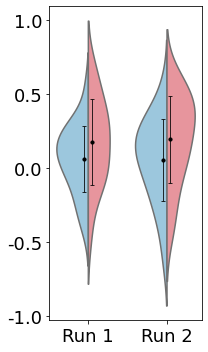

wilcoxon 119.0 0.7804932594299316
wilcoxon 81.0 0.09812235832214355


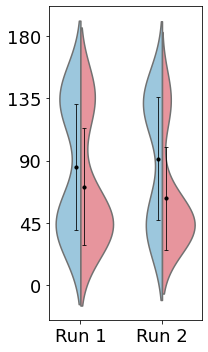

wilcoxon 10.5 0.028294807772043074
wilcoxon 7.0 0.005046016318523458


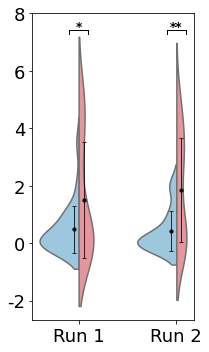

In [15]:
# For joyful relaxation NF analysis with two runs
for target_metric in ["correlation", "angular_distance", "intensity"]:
    compare_init_final(target_cond_idx = 2, target_metric = target_metric, compare_level = "block", block_mode = "-median")

t-test 3.2673333306281203 0.012241213393196552


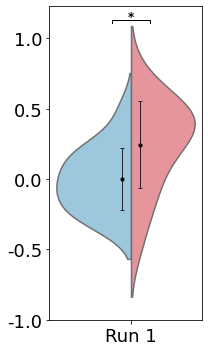

wilcoxon 12.0 0.01708984375


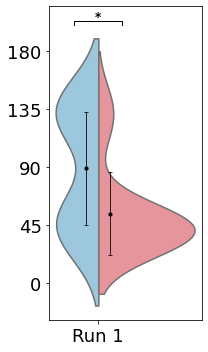

t-test 2.420358713169857 0.061768717320580896


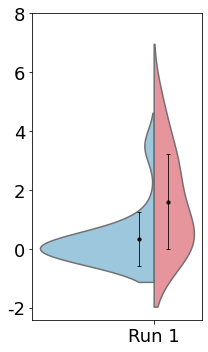

In [16]:
# For sadness NF analysis with only one run
for target_metric in ["correlation", "angular_distance", "intensity"]:
    compare_init_final(target_cond_idx = 3, target_metric = target_metric, compare_level = "block", block_mode = "-median")
